In [10]:
import pybamm
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math
import dfols
import signal
from tqdm import tqdm
from scipy.integrate import solve_ivp
from scipy.fft import fft, fftfreq, fftshift
from scipy.signal import savgol_filter
from scipy.signal import find_peaks
from scipy import interpolate, integrate
from stopit import threading_timeoutable as timeoutable
import os, sys
sys.path.append(os.path.dirname(os.path.dirname(os.path.abspath("__file__"))))
from batfuns import *
plt.rcParams = set_rc_params(plt.rcParams)
import winsound
from pybamm import exp, constants, Parameter
import pickle
import seaborn as sns

pd.options.mode.chained_assignment = None

eSOH_DIR = "../data/esoh_R/"
oCV_DIR = "../data/ocv/"
cyc_DIR = "../data/cycling/"
fig_DIR = "../figures/figures_fit/"
res_DIR = "../data/results_paper/"
resistance_DIR = "../data/resistance/"
%matplotlib widget

In [11]:
def get_cdf(cell,n=0):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    print(N1[-1])
    df = data[data["Cycle number"]==N1[n]]
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    return df

In [12]:
def get_chdh(cell,n=0):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    df = data[data["Cycle number"]==N1[n]]
    if n == 1 and cell == 31:
        df = df.drop(df.index[0])
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    E = df["Expansion [mu m]"].to_numpy()
    E = E-E[0]
    T = df["Temperature [C]"].to_numpy()
    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    E_ch = E[:idx-1]
    T_ch = T[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    E_dh = E[idx+1:]
    T_dh = T[idx+1:]
    df_ch = pd.DataFrame({"t":t_ch/3600,"Q":Q_ch,"I":I_ch,"V":V_ch,"E":E_ch,"T":T_ch})
    df_dh = pd.DataFrame({"t":t_dh/3600,"Q":Q_dh,"I":I_dh,"V":V_dh,"E":E_dh,"T":T_dh})
    return df_ch,df_dh

## Temp and Exp vs Time

In [13]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

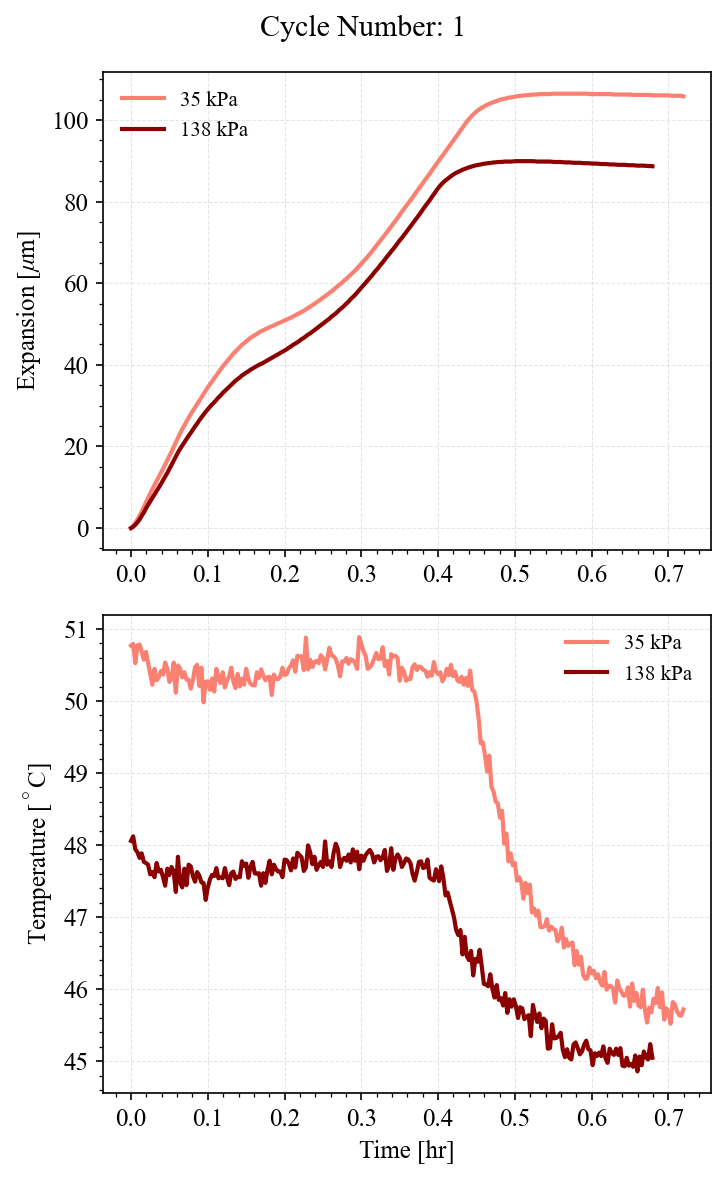

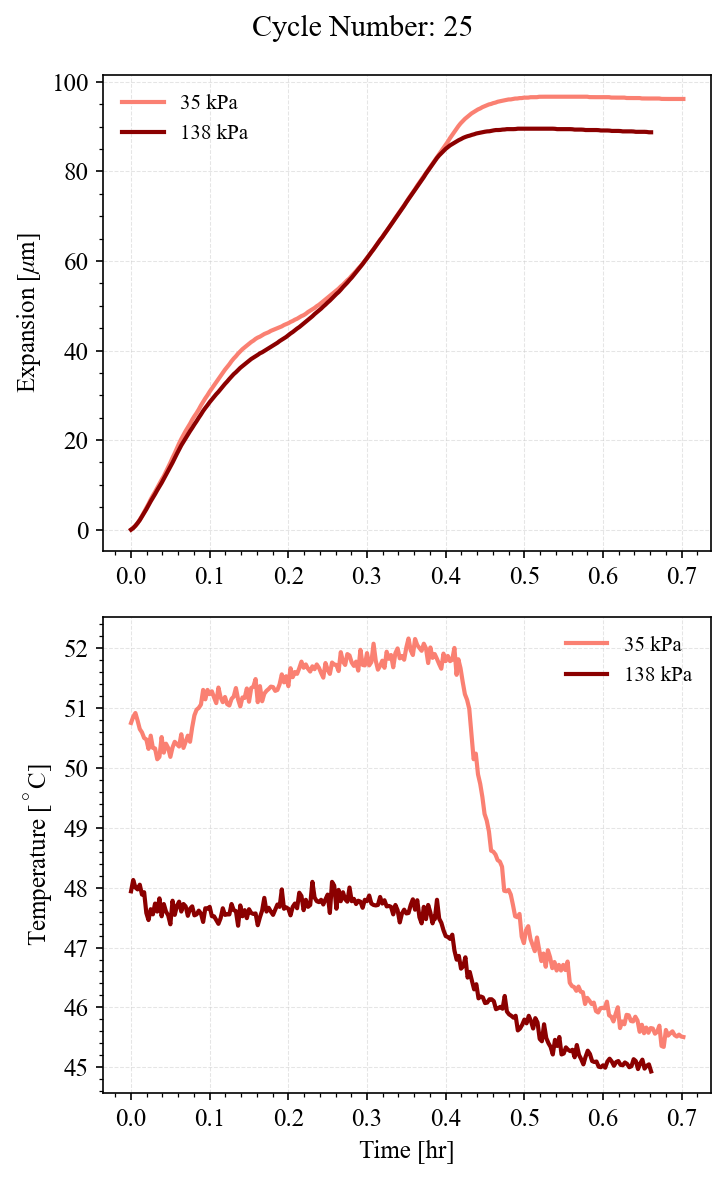

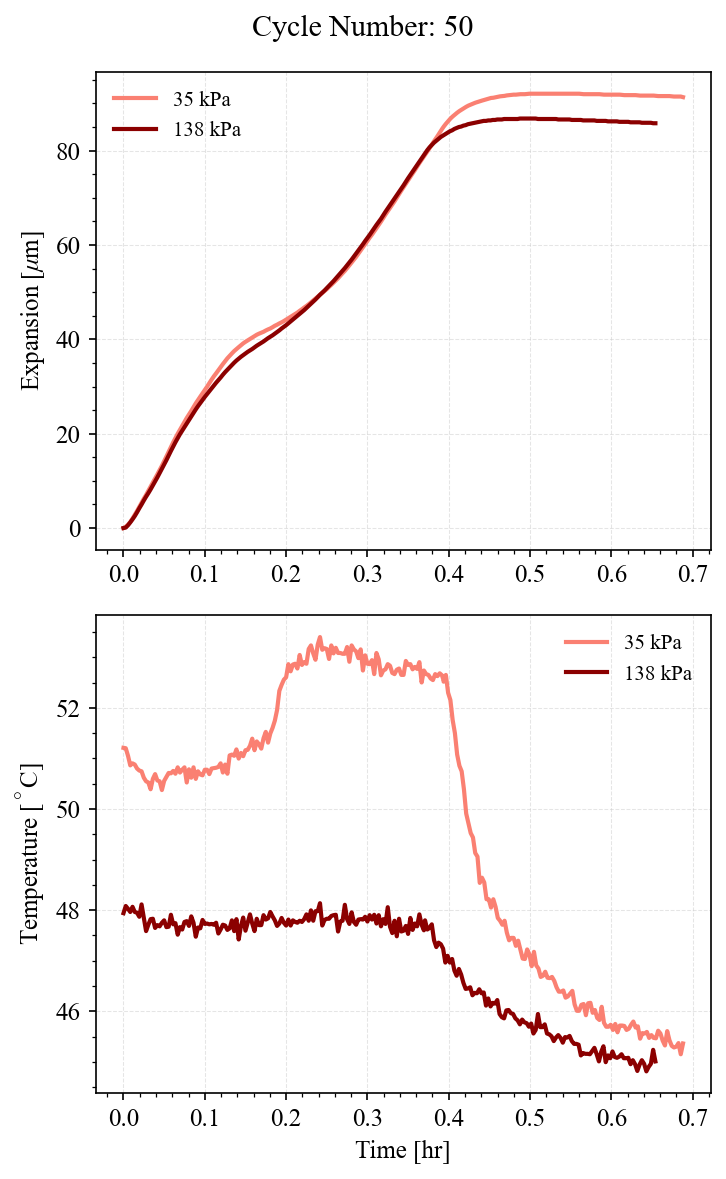

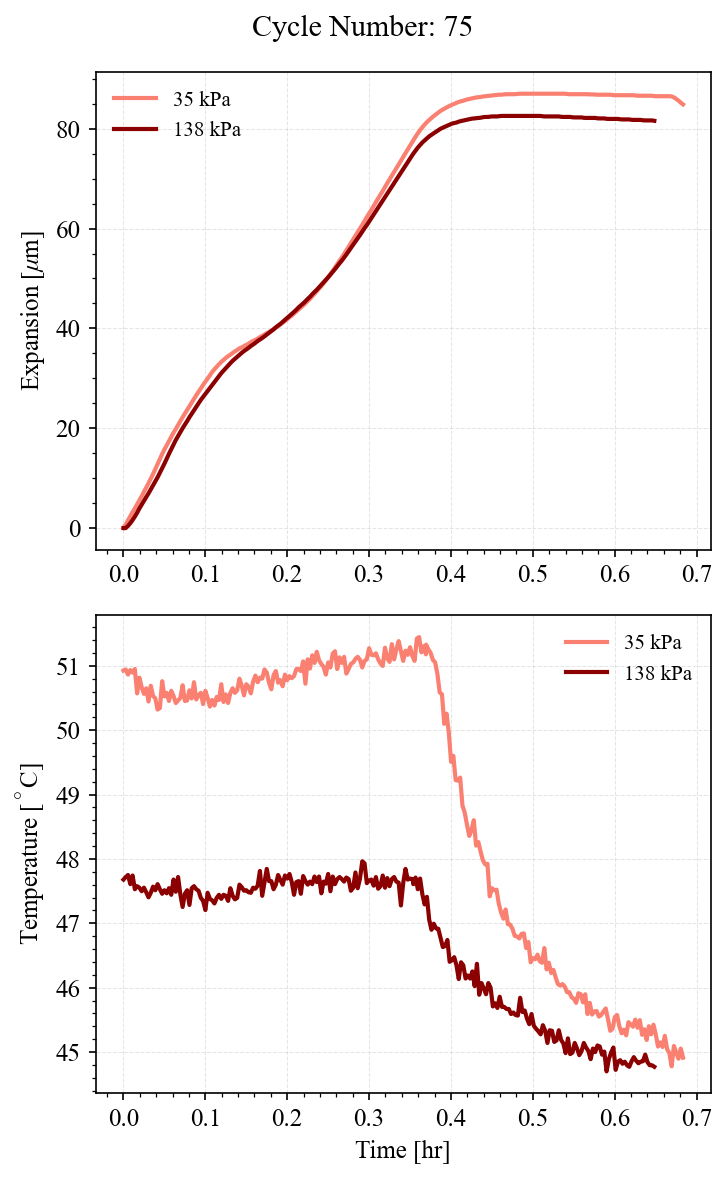

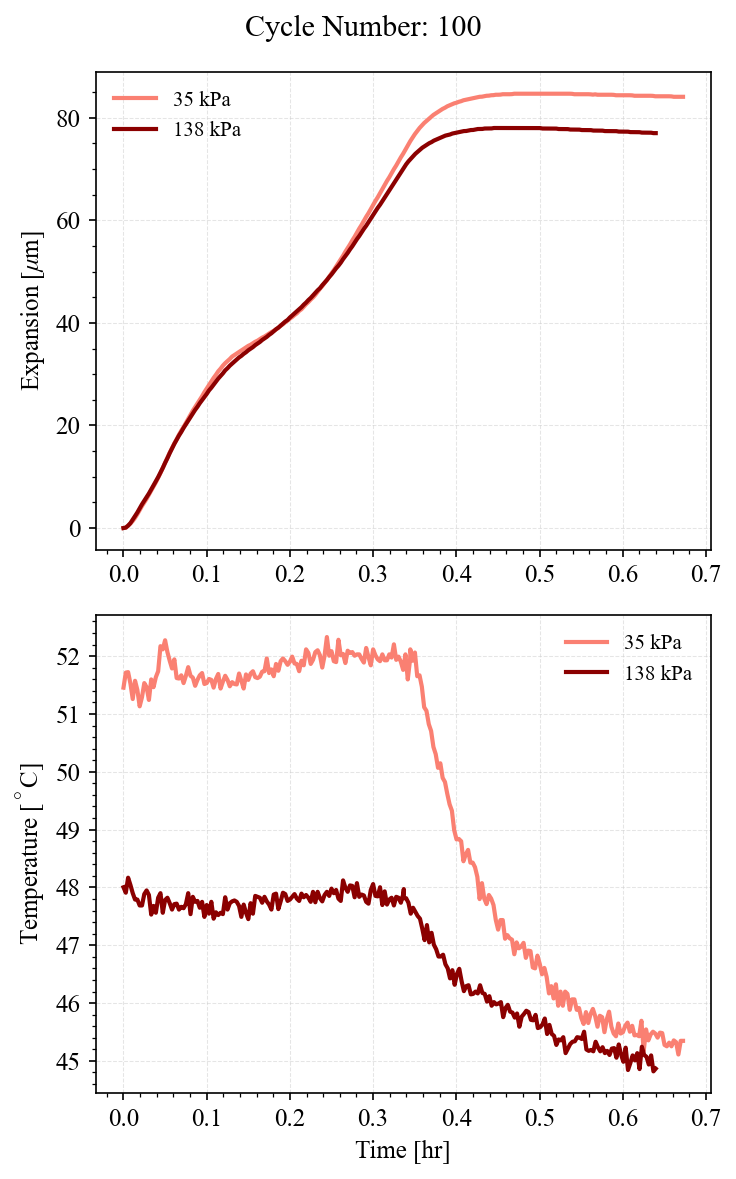

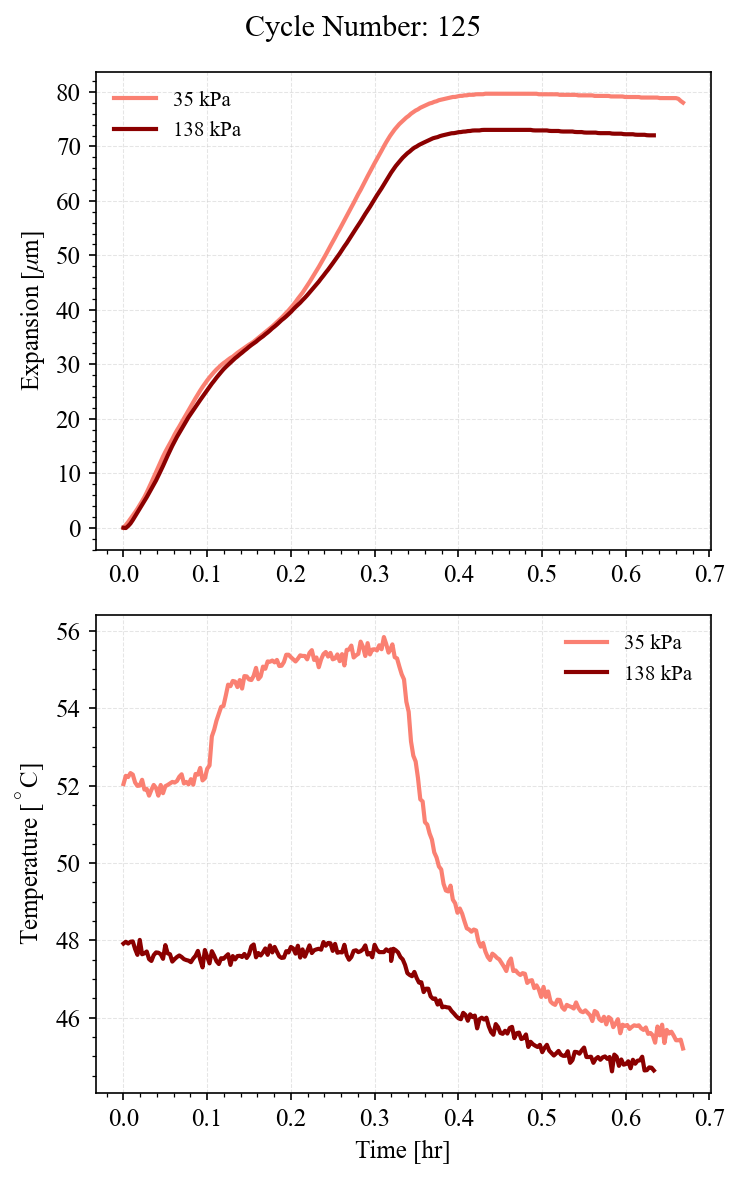

In [14]:
for n in [1,25,50,75,100,125]:
    df1_ch,df1_dh = get_chdh(9,n=n)
    df4_ch,df4_dh = get_chdh(33,n=n)
    fig, ax = plt.subplots(2,1,figsize=(5,8))
    ax1 = ax.flat[0]
    ax1.plot(df1_ch["t"],df1_ch["E"],color=colors[1])
    ax1.plot(df4_ch["t"],df4_ch["E"],color=colors[4])
    ax1.legend(["35 kPa","138 kPa"])
    ax1.set_ylabel(r"Expansion [$\mu$m]")
    ax2 = ax.flat[1]
    ax2.plot(df1_ch["t"],df1_ch["T"],color=colors[1])
    ax2.plot(df4_ch["t"],df4_ch["T"],color=colors[4])
    ax2.legend(["35 kPa","138 kPa"])
    ax2.set_ylabel(r"Temperature [$^\circ$C]")
    ax2.set_xlabel("Time [hr]")
    fig.suptitle(f"Cycle Number: {n}")
    fig.tight_layout()
    plt.show()
    fig.savefig(fig_DIR + f"Temp_Exp_comp_35_138_cycle_{n:03d}.png")

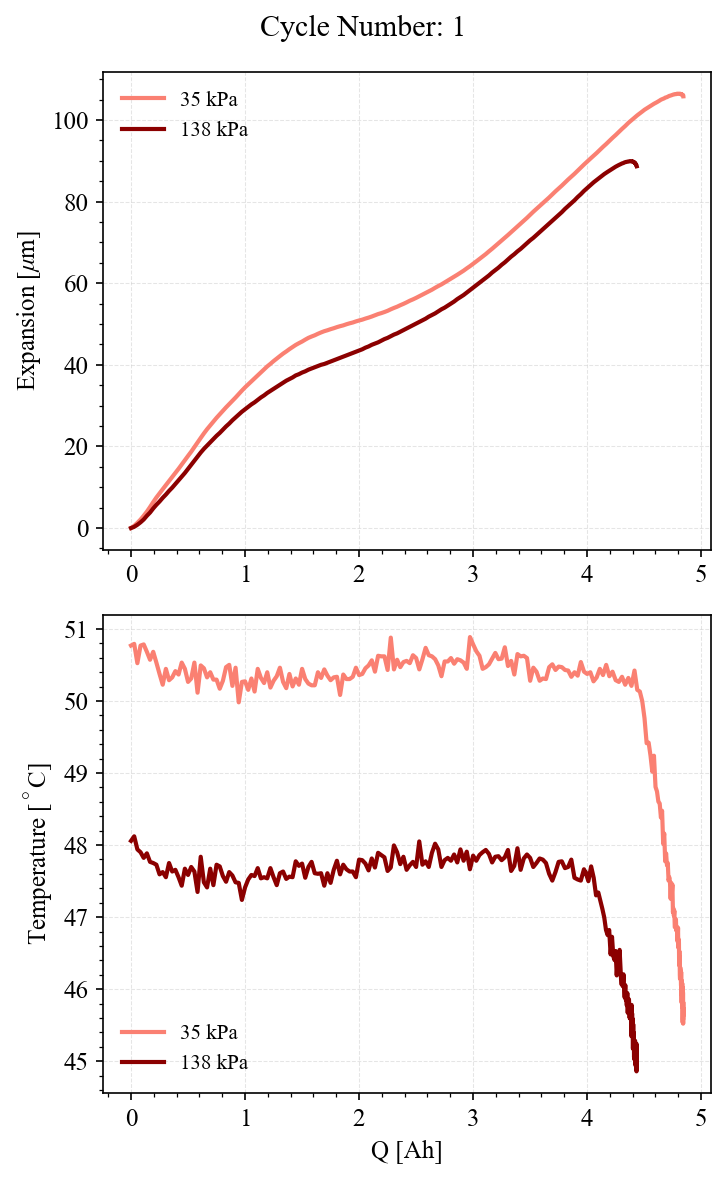

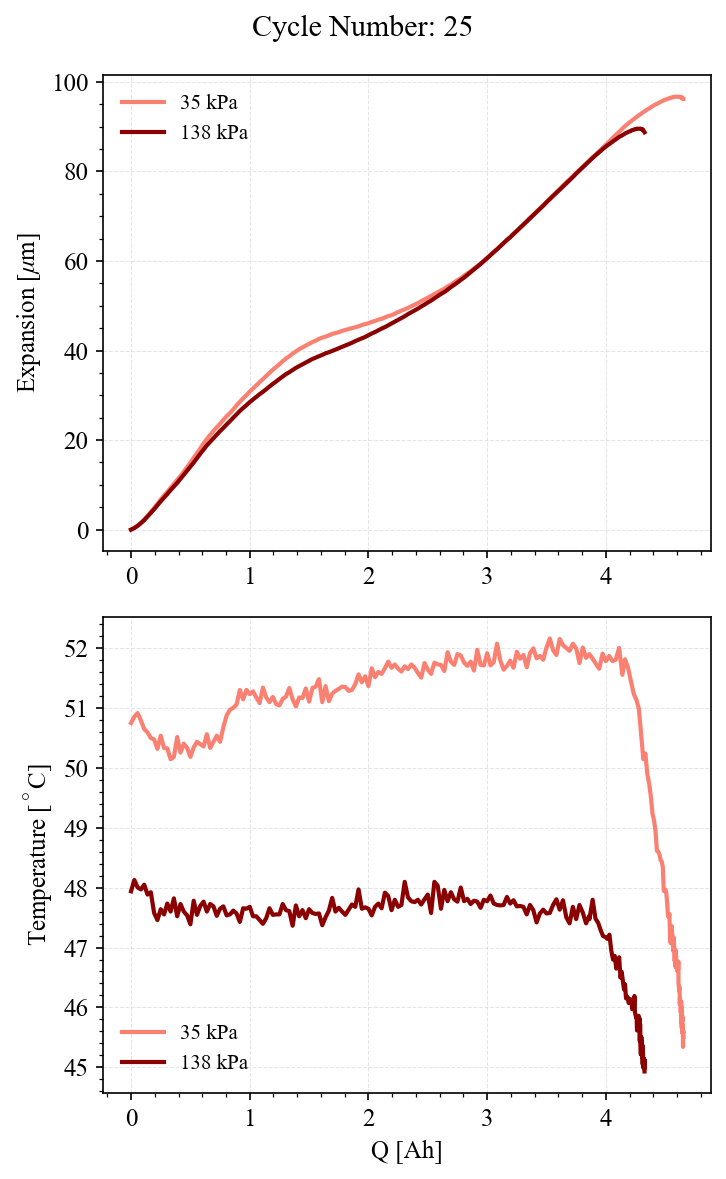

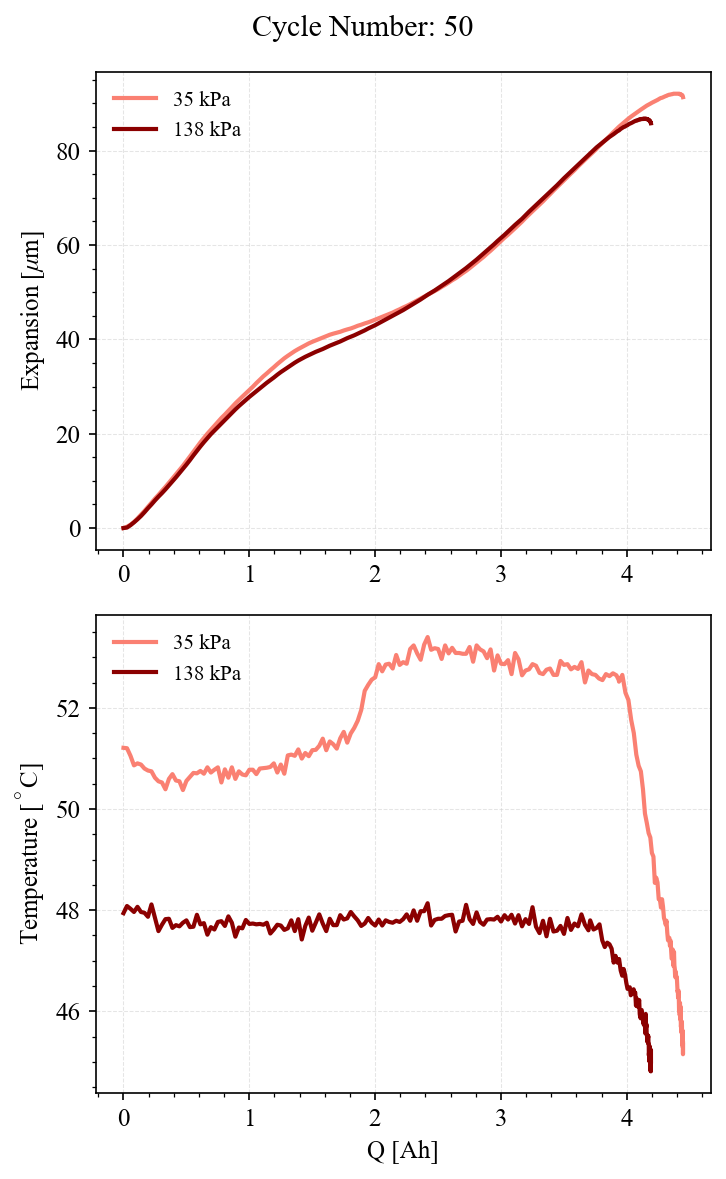

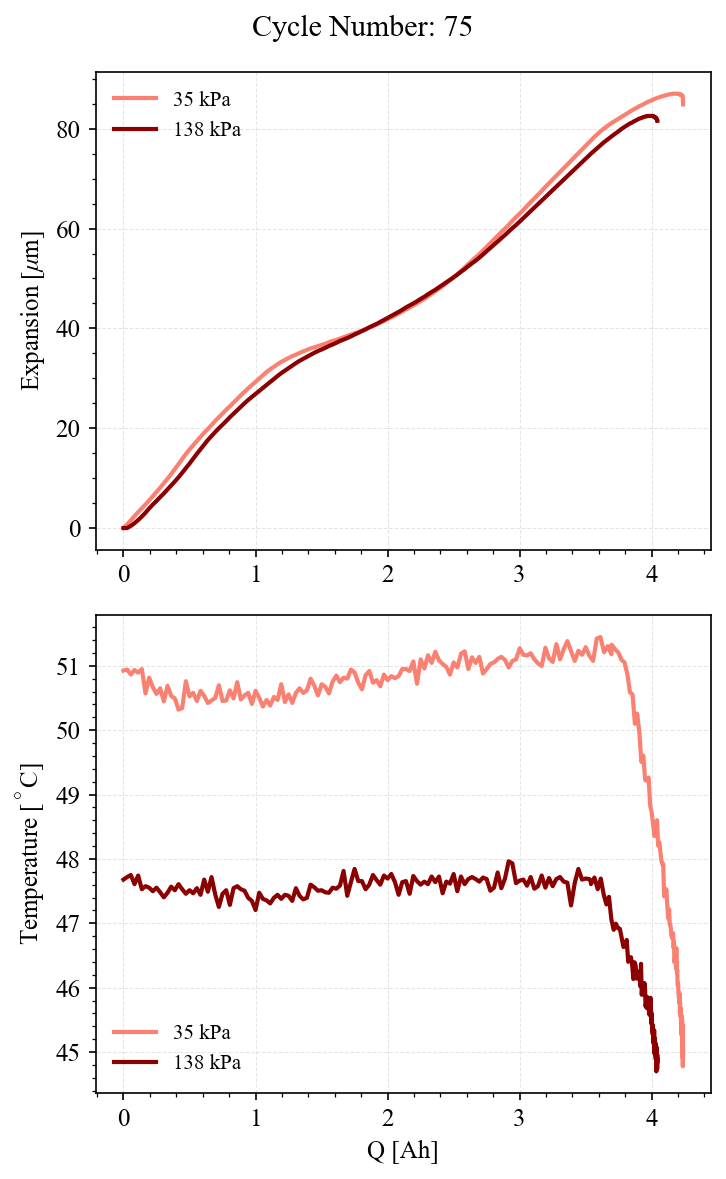

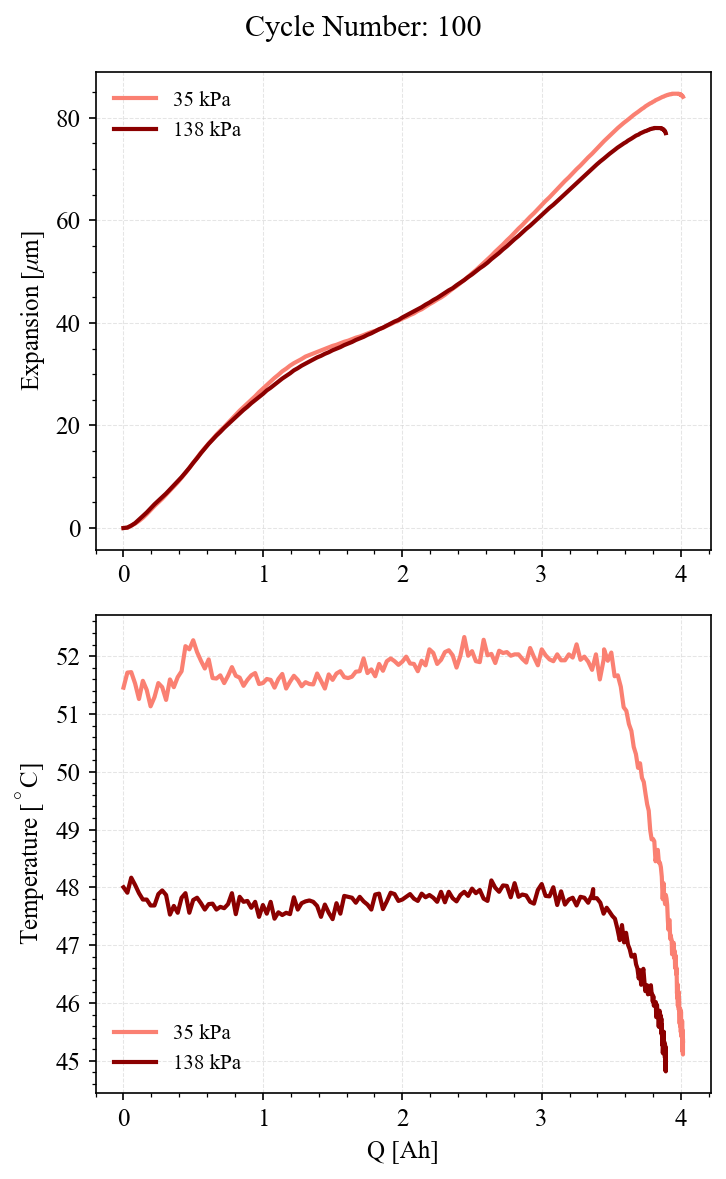

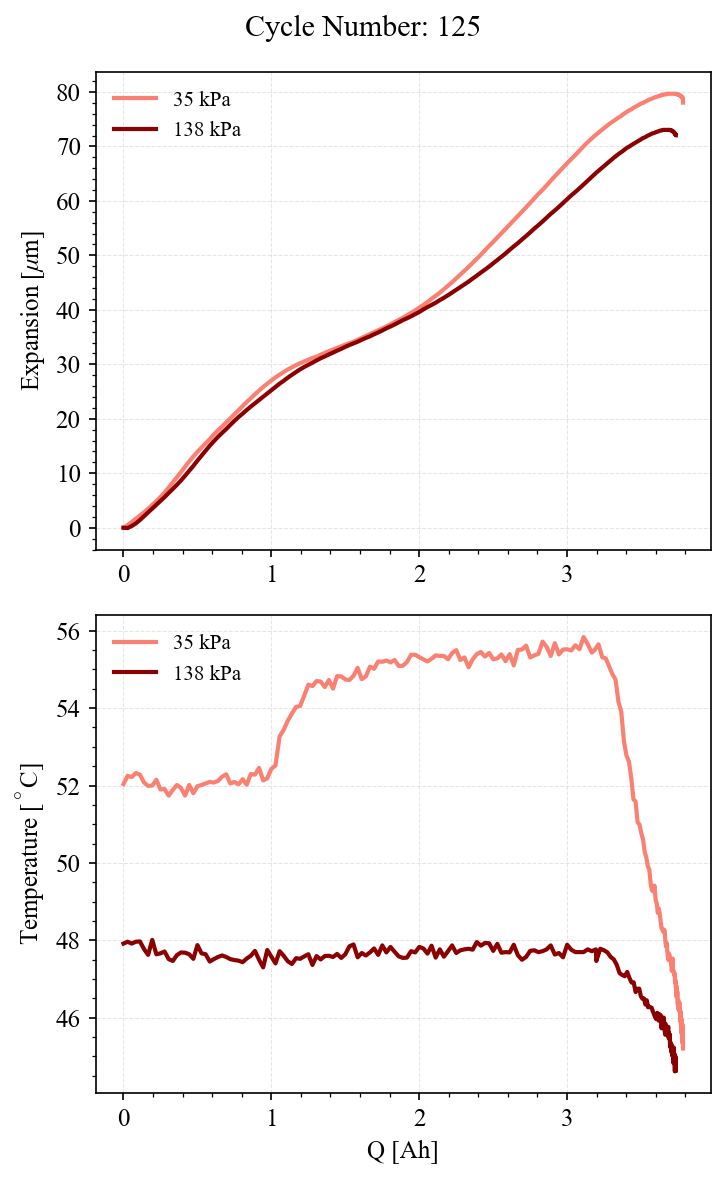

In [15]:
for n in [1,25,50,75,100,125]:
    df1_ch,df1_dh = get_chdh(9,n=n)
    df4_ch,df4_dh = get_chdh(33,n=n)
    fig, ax = plt.subplots(2,1,figsize=(5,8))
    ax1 = ax.flat[0]
    ax1.plot(df1_ch["Q"],df1_ch["E"],color=colors[1])
    ax1.plot(df4_ch["Q"],df4_ch["E"],color=colors[4])
    ax1.legend(["35 kPa","138 kPa"])
    ax1.set_ylabel(r"Expansion [$\mu$m]")
    ax2 = ax.flat[1]
    ax2.plot(df1_ch["Q"],df1_ch["T"],color=colors[1])
    ax2.plot(df4_ch["Q"],df4_ch["T"],color=colors[4])
    ax2.legend(["35 kPa","138 kPa"])
    ax2.set_ylabel(r"Temperature [$^\circ$C]")
    ax2.set_xlabel("Q [Ah]")
    fig.suptitle(f"Cycle Number: {n}")
    fig.tight_layout()
    plt.show()
    fig.savefig(fig_DIR + f"Temp_Exp_comp_35_138_cycle_Q_{n:03d}.png")

In [16]:
# df0 = get_exp_peaks(26)
# df1 = get_exp_peaks(9)
# df2 = get_exp_peaks(29)
# df3 = get_exp_peaks(31)
# df4 = get_exp_peaks(33)
# df5 = get_exp_peaks(35)

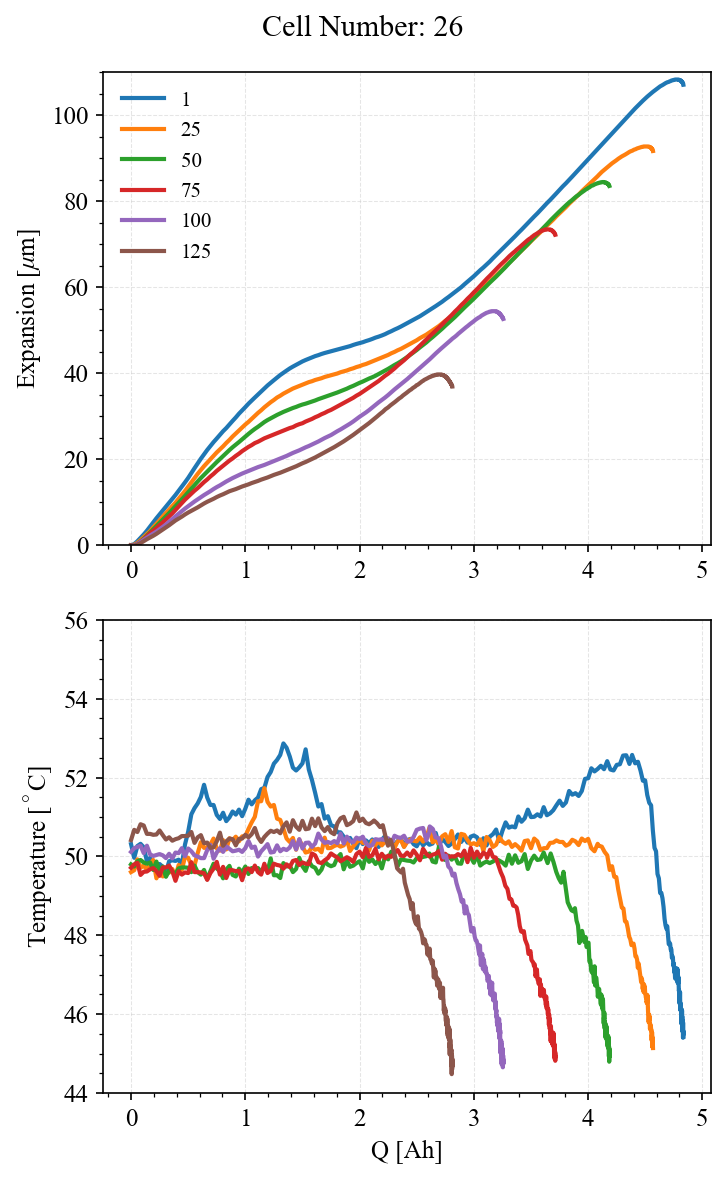

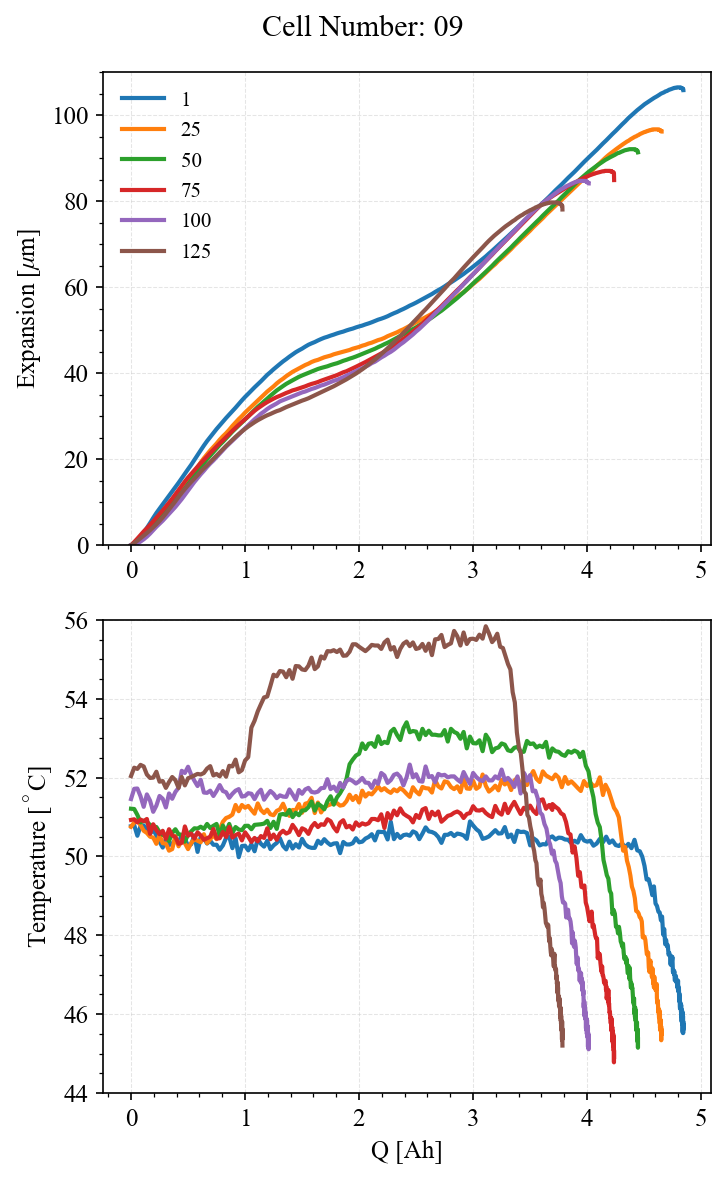

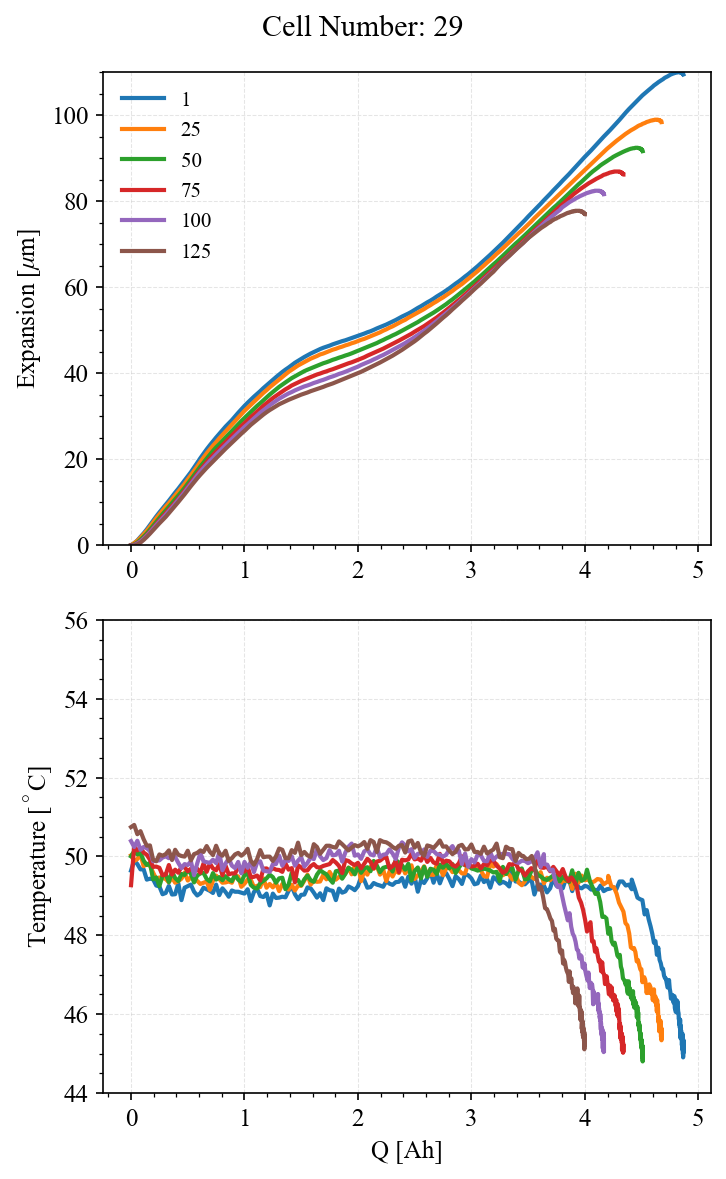

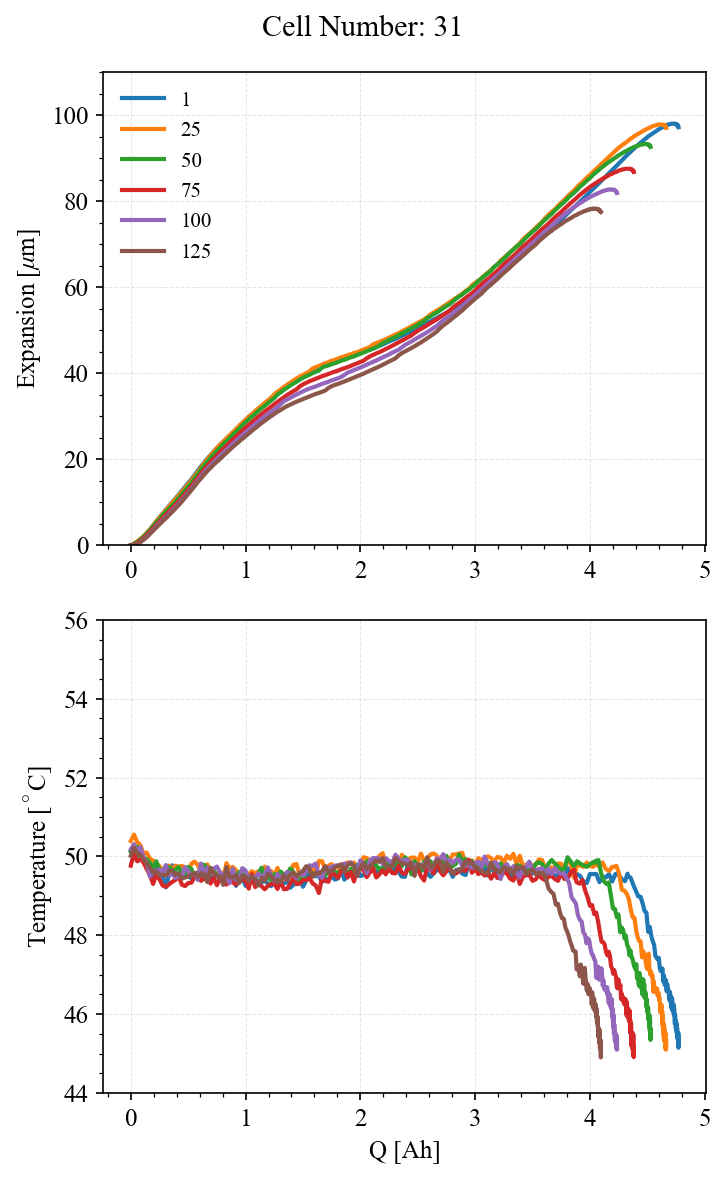

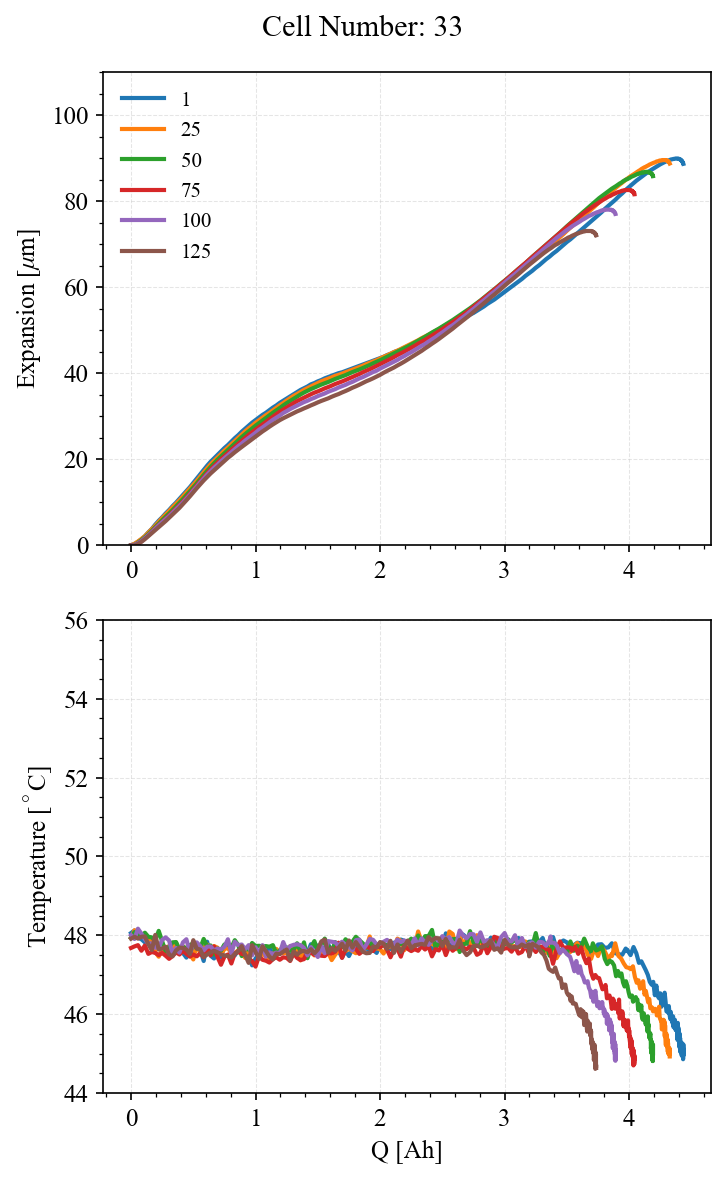

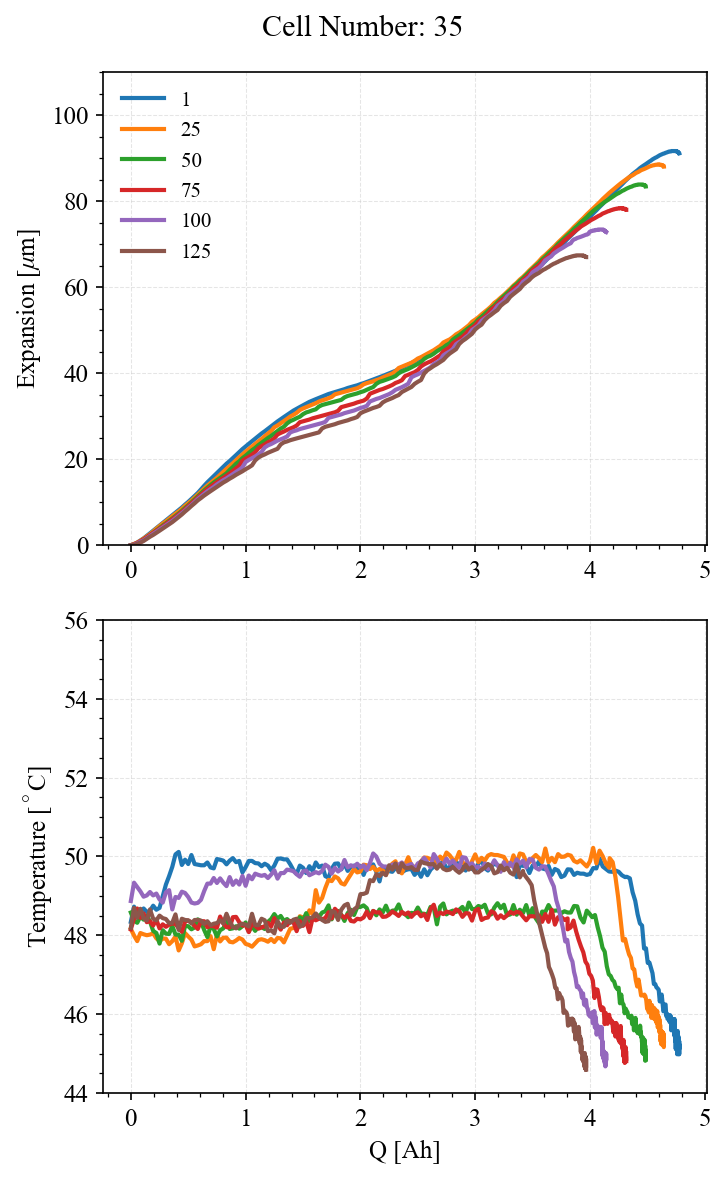

In [17]:
for c in [26,9,29,31,33,35]:
    fig, ax = plt.subplots(2,1,figsize=(5,8))
    for n in [1,25,50,75,100,125]:
        df4_ch,df4_dh = get_chdh(c,n=n)
        ax1 = ax.flat[0]
        ax1.plot(df4_ch["Q"],df4_ch["E"])
        ax1.set_ylabel(r"Expansion [$\mu$m]")
        ax1.set_ylim([0,110])
        ax2 = ax.flat[1]
        ax2.plot(df4_ch["Q"],df4_ch["T"])
        ax2.set_ylabel(r"Temperature [$^\circ$C]")
        ax2.set_xlabel("Q [Ah]")
        ax2.set_ylim([44,56])
    fig.suptitle(f"Cell Number: {c:02d}")
    ax1.legend([1,25,50,75,100,125])
    fig.tight_layout()
    plt.show()
    fig.savefig(fig_DIR + f"Temp_Exp_comp_{c:02d}_cycle_all_Q.png")

In [18]:
sdfsdf

NameError: name 'sdfsdf' is not defined

In [19]:
def get_exp_peaks(cell):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            # window_length=61
            # polyorder=3
            # window_length=81
            # polyorder=2
            window_length=71
            polyorder=4
            if cell == 26:
                window_length=61
                polyorder=4
            
            if len(t)>1000:
                window_length=501

            Qmax = np.round(Q_ch[-1],3)
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            # pks = np.append(pks1,pks2)
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            

            # Q_chi = np.arange(0,Q_ch[-1],0.0001)
            # int_dEdQ2 = interpolate.interp1d(Q_ch,dEdQ2, fill_value="extrapolate")
            # dEdQ2i = int_dEdQ2(Q_chi)
            # S_chi = Q_chi/max(Q_chi)
            # pks_,_ = find_peaks(-dEdQ2i,height=0.01,width=0.1)
            # pks1 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            # pks_,_ = find_peaks(dEdQ2i,height=0.01,width=0.1)
            # pks2 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
            # p1s = np.round(S_chi[pks1[0]],4)
            # p2s = np.round(S_chi[pks2[0]],4)
            # p1q = np.round(Q_chi[pks1[0]],3)
            # p2q = np.round(Q_chi[pks2[0]],3)
        
            

            dE3 = savgol_filter(E_ch,window_length,polyorder,3)
            dEdQ3 = dE3/dQ/dQ/dQ

            int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=True)
            Q_chi = np.arange(0,Qmax,0.0001)
            S_chi = Q_chi/max(Q_chi)
            dEdQ3i = int_dEdQ3(Q_chi)
            zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
            zc = zc[0:2]
            p1s = np.round(S_chi[zc[0]],4)
            p2s = np.round(S_chi[zc[1]],4)
            p1q = np.round(Q_chi[zc[0]],3)
            p2q = np.round(Q_chi[zc[1]],3)

            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except Exception as error:
            # print(error)
            pass
    df2 = pd.concat(dfa)
    df2 = df2.reset_index(drop=True)
    return df2

In [20]:
# df0 = get_exp_peaks(26)
# df1 = get_exp_peaks(9)
# df2 = get_exp_peaks(29)
# df3 = get_exp_peaks(31)
# df4 = get_exp_peaks(33)
# df5 = get_exp_peaks(35)

Text(0, 0.5, 'Expansion 3rd derivative')

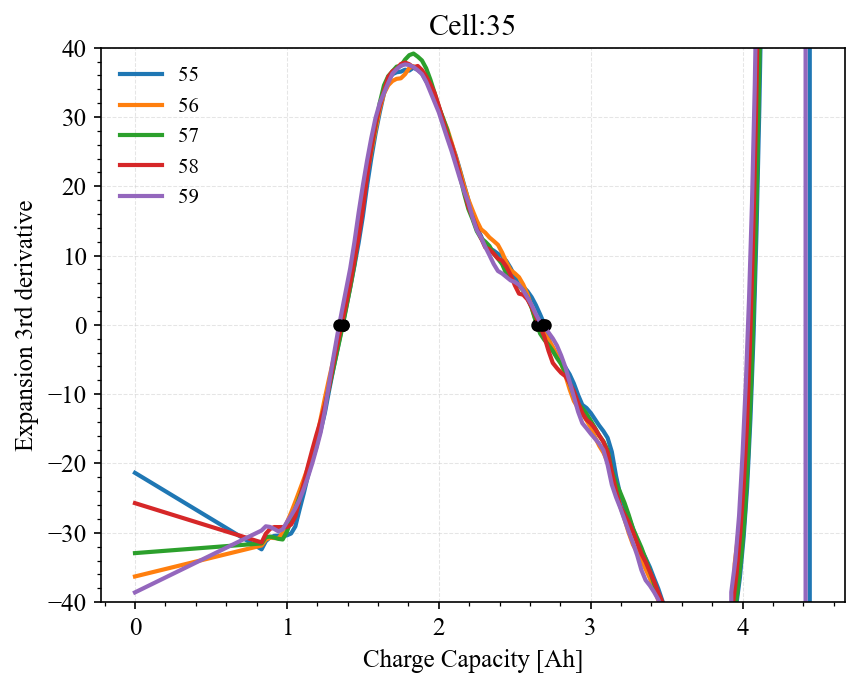

In [21]:
cell = 35
cell_no = f'{cell:02d}'
data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
N1 = np.unique(data["Cycle number"])
fig,ax = plt.subplots(1,1)   
n1 = 55
cycles = range(n1,n1+5,1)
for n in cycles:
    df = data[data["Cycle number"]==N1[n]]
    df = df.dropna()
    df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
    df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
    t = df["Time [s]"].to_numpy()
    I = df["Current [mA]"].to_numpy()/1000
    V = df["Voltage [V]"].to_numpy()
    Q = df["Q [Ah]"].to_numpy()
    Cap = df["Capacity [Ah]"].to_numpy()
    E = df["Expansion [mu m]"].to_numpy()
    E = E-E[0]

    idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
    idx = idxi1[0]
    t_ch = t[:idx-1]
    I_ch = I[:idx-1]
    V_ch = V[:idx-1]
    Q_ch = Cap[:idx-1]
    E_ch = E[:idx-1]
    t_dh = t[idx+1:]-t[idx+1]
    I_dh = I[idx+1:]
    V_dh = V[idx+1:]
    Q_dh = Cap[idx+1:]
    E_dh = E[idx+1:]
    window_length=61
    polyorder=4
    if len(t)>1000:
        window_length=501
    S_ch = Q_ch/max(Q_ch)
    dQ = savgol_filter(Q_ch,window_length,polyorder,1)
    dE2 = savgol_filter(E_ch,window_length,polyorder,2)
    dE3 = savgol_filter(E_ch,window_length,polyorder,3)
    dE2 = dE2*(S_ch<=0.95)
    dEdQ2 = dE2/dQ/dQ
    dEdQ3 = dE3/dQ/dQ/dQ
    Qmax = np.round(Q_ch[-1],3)
    # pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
    # pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    # pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
    # pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
    # pks = np.append(pks1,pks2)

    Q_chi = np.arange(0,Q_ch[-1],0.0001)
    S_chi = Q_chi/max(Q_chi)

    # int_dEdQ2 = interpolate.interp1d(Q_ch,dEdQ2, fill_value="extrapolate")
    # dEdQ2i = int_dEdQ2(Q_chi)
    # pks_,_ = find_peaks(-dEdQ2i,height=0.01,width=0.1)
    # pks1 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]
    # pks_,_ = find_peaks(dEdQ2i,height=0.01,width=0.1)
    # pks2 = [pk for pk in pks_ if S_chi[pk]>=0.1 and S_chi[pk]<=0.9]


    int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=True)
    dEdQ3i = int_dEdQ3(Q_chi)
    zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
    zc = zc[0:2]

    int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=False)
    dEdQ3i = int_dEdQ3(Q_chi)
    zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
    zc = zc[1:3]
    # ax.plot(t_ch,E_ch)
    # ax.plot(Q_ch,dEdQ2)
    # ax.plot(Q_ch[pks1[0]],dEdQ2[pks1[0]],'ko',label='_nolegend_')
    # ax.plot(Q_ch[pks2[0]],dEdQ2[pks2[0]],'ko',label='_nolegend_')
    # ax.plot(Q_chi,dEdQ2i)
    # ax.plot(Q_chi[pks1[0]],dEdQ2i[pks1[0]],'ko',label='_nolegend_')
    # ax.plot(Q_chi[pks2[0]],dEdQ2i[pks2[0]],'ko',label='_nolegend_')
    ax.plot(Q_ch,dEdQ3)
    ax.plot(Q_chi[zc],dEdQ3i[zc],'ko',label="_nolegend_")
    ax.set_ylim([-40,40])
ax.legend(cycles)
ax.set_title("Cell:"+cell_no)
ax.set_xlabel("Charge Capacity [Ah]")
ax.set_ylabel("Expansion 3rd derivative")

In [30]:
def get_exp_peaks(cell):
    cell_no = f'{cell:02d}'
    data = pd.read_csv(cyc_DIR+"cycling_data_cell_"+cell_no+".csv")
    N1 = np.unique(data["Cycle number"])
    # print(N1[-1])
    dfa = []
    for n in N1:
        try:
            df = data[data["Cycle number"]==N1[n]]
            df = df.dropna()
            df["Time [s]"] = df["Time [s]"] - df["Time [s]"].iloc[0]
            df["Q [Ah]"] = df["Q [Ah]"] - df["Q [Ah]"].iloc[0]
            t = df["Time [s]"].to_numpy()
            I = df["Current [mA]"].to_numpy()/1000
            V = df["Voltage [V]"].to_numpy()
            Q = df["Q [Ah]"].to_numpy()
            Cap = df["Capacity [Ah]"].to_numpy()
            E = df["Expansion [mu m]"].to_numpy()
            E = E-E[0]
        
            idxi1 = np.where((np.diff(I)<-1) & (I[:-1]>0) & (I[:-1]<2))[0]
            idx = idxi1[0]
            t_ch = t[:idx-1]
            I_ch = I[:idx-1]
            V_ch = V[:idx-1]
            Q_ch = Cap[:idx-1]
            E_ch = E[:idx-1]
            t_dh = t[idx+1:]-t[idx+1]
            I_dh = I[idx+1:]
            V_dh = V[idx+1:]
            Q_dh = Cap[idx+1:]
            E_dh = E[idx+1:]
            # window_length=61
            # polyorder=3
            # window_length=81
            # polyorder=2
            window_length=81
            polyorder=4
            if cell == 26:
                window_length=61
                polyorder=4
            if len(t)>1000:
                window_length=501

            Qmax = np.round(Q_ch[-1],3)
            S_ch = Q_ch/max(Q_ch)
            dQ = savgol_filter(Q_ch,window_length,polyorder,1)
            dE2 = savgol_filter(E_ch,window_length,polyorder,2)
            dE2 = dE2*(S_ch<=0.95)
            dEdQ2 = dE2/dQ/dQ
            pks_,_ = find_peaks(-dEdQ2,height=0.01,width=0.1)
            pks1 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            pks_,_ = find_peaks(dEdQ2,height=0.01,width=0.1)
            pks2 = [pk for pk in pks_ if S_ch[pk]>=0.1 and S_ch[pk]<=0.9]
            # pks = np.append(pks1,pks2)
            p1s = np.round(S_ch[pks1[0]],4)
            p2s = np.round(S_ch[pks2[0]],4)
            p1q = np.round(Q_ch[pks1[0]],3)
            p2q = np.round(Q_ch[pks2[0]],3)
            
            dE3 = savgol_filter(E_ch,window_length,polyorder,3)
            dEdQ3 = dE3/dQ/dQ/dQ

            int_dEdQ3 = interpolate.CubicSpline(Q_ch,dEdQ3,extrapolate=True)
            Q_chi = np.arange(0,Qmax,0.0001)
            S_chi = Q_chi/max(Q_chi)
            dEdQ3i = int_dEdQ3(Q_chi)
            zc = np.where(np.diff(np.sign(dEdQ3i)))[0]
            zc = zc[0:2]
            p1s = np.round(S_chi[zc[0]],4)
            p2s = np.round(S_chi[zc[1]],4)
            p1q = np.round(Q_chi[zc[0]],3)
            p2q = np.round(Q_chi[zc[1]],3)

            df1 = pd.DataFrame({"N":n+1,"p1s":p1s,"p2s":p2s,"p1q":p1q,"p2q":p2q,"Qch":Qmax},index=[0])
            df1["ds"] = df1["p2s"] - df1["p1s"]
            df1["dq"] = df1["p2q"] - df1["p1q"]
            dfa.append(df1)
        except Exception as error:
            # print(error)
            pass
    df2 = pd.concat(dfa)
    df2 = df2.reset_index(drop=True)
    return df2

In [31]:
df5_1 = get_exp_peaks(35)

In [24]:
df5 = get_exp_peaks(35)

Text(0, 0.5, '$\\Delta C_n$')

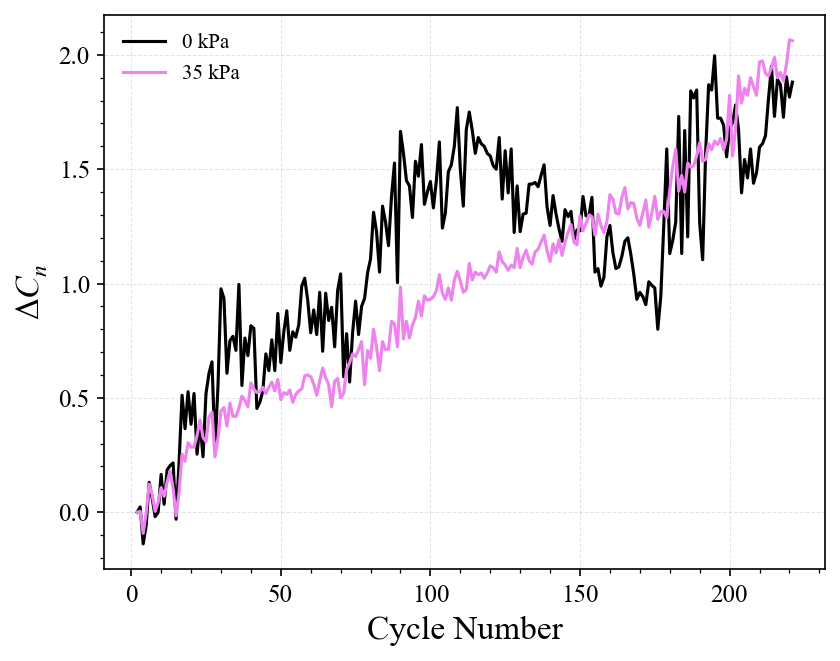

In [32]:
colors = ["violet","salmon","darkorange","red","darkred","black"]

fig, ax = plt.subplots(1,1,figsize=(6.2,4.8))
ax.plot(df5["N"],df5["dq"].iloc[0]/(0.5-0.24)-df5["dq"]/(0.5-0.24),color=colors[5],linewidth=1.5)
ax.plot(df5_1["N"],df5_1["dq"].iloc[0]/(0.5-0.24)-df5_1["dq"]/(0.5-0.24),color=colors[0],linewidth=1.5)

# ax.legend(['0 psi','5 psi','10 psi','15 psi','20 psi','25 psi'])
ax.legend(['0 kPa','35 kPa','69 kPa','103 kPa','138 kPa','172 kPa'])
# ax.legend(['0 psi','10 psi','15 psi','20 psi','25 psi','sim'])
# ax.set_ylim([3,6.5])
ax.set_xlabel("Cycle Number",fontsize=16)
ax.set_ylabel(r"$\Delta C_n$",fontsize=16)